In [1]:
import pandas as pd
import ast
import argparse
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import math


## Load data

In [70]:
base_annotation_dir = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/08_IE_full_text/model_predictions"

dataset_fulltext = pd.read_csv(f"{base_annotation_dir}/full_text_combined_all_annotations_metadata.csv")
dataset_fulltext.shape

/tmp/ipykernel_2133017/2944385058.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  dataset_fulltext = pd.read_csv(f"{base_annotation_dir}/full_text_combined_all_annotations_metadata.csv")


(371832, 21)

In [71]:
cols_to_format = ["animal_species", "animal_sex", "animal_strain", "assay_type"]

for c in cols_to_format:
    dataset_fulltext[c] = (
        dataset_fulltext[c]
        .where(dataset_fulltext[c].isna(), dataset_fulltext[c].astype(str))
        .str.replace("_", " ", regex=False)
        .str.replace("-", " ", regex=False)
        .str.replace(" & ", "&", regex=False)
        .str.title()
    )


In [72]:
dataset_fulltext["animal_sex"] = dataset_fulltext["animal_sex"].str.replace(
    "Sex Not Reported", "Not Reported", regex=False
)


In [73]:
dataset_fulltext.head()

,PMID,animal_sex,animal_species,rigor_blinding,rigor_randomization,rigor_welfare,assay_type,animal_strain,animal_number,sample_size,...,merged_mondo_label,merged_mondo_termid,merged_umls_label,merged_umls_termid,unique_conditions_linkbert_predictions,unique_interventions_linkbert_predictions,year,journal_name,publication_type,title
0,1000129,Not Reported,Mouse,blinding-not-reported,randomization-not-reported,welfare-not-reported,Not Reported,Not Reported,not reported,sample-size-not-reported,...,audiogenic si|audiogenic seizures,-1|MONDO:0015644,Naloxone|Morphine,C0027358|C0026549,audiogenic si|audiogenic seizures,naloxone|morphine,1976.0,British journal of pharmacology,Journal Article,Effect of morphine and naloxone on priming-ind...
1,1000338,Not Reported,Rat,blinding-not-reported,randomization-present,welfare-not-reported,"Histology, Molecular&Cellular",Not Reported,not reported,sample-size-not-reported,...,vitamin D deficiency,MONDO:0100471,VITAMIN D,C3714503,vitamin d deficient,vitamin d,1976.0,Calcified tissue research,"Journal Article+Research Support, U.S. Gov't, ...",A morphometric investigation of the duodenal m...
2,10021294,Not Reported,Mouse,blinding-not-reported,randomization-not-reported,welfare-not-reported,Not Reported,Not Reported,45.0,sample-size-not-reported,...,ovarian carcinoma|ovarian neoplasm,MONDO:0005140|MONDO:0021068,"Il12a protein, mouse|Interleukin 12|Edodekin a...",C1700202|C0123759|C3665495|C1121403,epithelial ovarian cancer|ovarian cancer|ovari...,murine il-12|il-12|murine interleuken (il)-12,1999.0,Gynecologic oncology,"Journal Article+Research Support, Non-U.S. Gov...",Effects of IL-12 on human ovarian tumors engra...
3,10021348,Not Reported,Mouse,blinding-not-reported,randomization-not-reported,welfare-not-reported,"Histology, Molecular&Cellular",Not Reported,not reported,sample-size-not-reported,...,obsolete cartilage disease,MONDO:0005569,Growth Differentiation Factor 5,C0253373,chondrody,gdf 5|gdf-5,1999.0,"Development (Cambridge, England)","Journal Article+Research Support, Non-U.S. Gov't",Mechanisms of GDF-5 action during skeletal dev...
4,10022166,Sex Female,Rat,blinding-not-reported,randomization-not-reported,welfare-not-reported,"Histology, Molecular&Cellular",Sprague Dawley,not reported,sample-size-not-reported,...,congenital diaphragmatic hernia,MONDO:0005711,Vitamin E,C0042874,congenital diaphragmatic hernia,vitamin e,1999.0,Journal of pediatric surgery,"Journal Article+Research Support, Non-U.S. Gov...",Prenatal vitamin E treatment improves lung gro...


In [74]:
dataset_fulltext = dataset_fulltext[dataset_fulltext['animal_species'].str.contains("Mouse")]
dataset_fulltext.shape

(171516, 21)

In [75]:
dataset_fulltext.head()

,PMID,animal_sex,animal_species,rigor_blinding,rigor_randomization,rigor_welfare,assay_type,animal_strain,animal_number,sample_size,...,merged_mondo_label,merged_mondo_termid,merged_umls_label,merged_umls_termid,unique_conditions_linkbert_predictions,unique_interventions_linkbert_predictions,year,journal_name,publication_type,title
0,1000129,Not Reported,Mouse,blinding-not-reported,randomization-not-reported,welfare-not-reported,Not Reported,Not Reported,not reported,sample-size-not-reported,...,audiogenic si|audiogenic seizures,-1|MONDO:0015644,Naloxone|Morphine,C0027358|C0026549,audiogenic si|audiogenic seizures,naloxone|morphine,1976.0,British journal of pharmacology,Journal Article,Effect of morphine and naloxone on priming-ind...
2,10021294,Not Reported,Mouse,blinding-not-reported,randomization-not-reported,welfare-not-reported,Not Reported,Not Reported,45.0,sample-size-not-reported,...,ovarian carcinoma|ovarian neoplasm,MONDO:0005140|MONDO:0021068,"Il12a protein, mouse|Interleukin 12|Edodekin a...",C1700202|C0123759|C3665495|C1121403,epithelial ovarian cancer|ovarian cancer|ovari...,murine il-12|il-12|murine interleuken (il)-12,1999.0,Gynecologic oncology,"Journal Article+Research Support, Non-U.S. Gov...",Effects of IL-12 on human ovarian tumors engra...
3,10021348,Not Reported,Mouse,blinding-not-reported,randomization-not-reported,welfare-not-reported,"Histology, Molecular&Cellular",Not Reported,not reported,sample-size-not-reported,...,obsolete cartilage disease,MONDO:0005569,Growth Differentiation Factor 5,C0253373,chondrody,gdf 5|gdf-5,1999.0,"Development (Cambridge, England)","Journal Article+Research Support, Non-U.S. Gov't",Mechanisms of GDF-5 action during skeletal dev...
15,10024230,Sex Male,Mouse,blinding-not-reported,randomization-not-reported,welfare-not-reported,"Histology, Molecular&Cellular",Not Reported,not reported,sample-size-not-reported,...,allergic asthma|asthma,MONDO:0004784|MONDO:0004979,antibodies to vbeta8,-1,allergic asthma,antibodies to vbeta8,1998.0,Clinical and experimental allergy : journal of...,"Journal Article+Research Support, Non-U.S. Gov't",Vbeta8+ T lymphocytes are essential in the reg...
17,10024383,Sex Both,Mouse,blinding-not-reported,randomization-not-reported,welfare-not-reported,Not Reported,Not Reported,not reported,sample-size-not-reported,...,of the posterior longitudinal ligament,-1,Calcitonin|chicken calcitonin,C0006668|-1,of the posterior longitudinal ligament,calcitonin|chicken calcitonin,1999.0,Calcified tissue international,"Journal Article+Research Support, Non-U.S. Gov't",Calcitonin simultaneously regulates both perio...


In [66]:
dataset_fulltext.rigor_welfare.unique()

array(['welfare-not-reported', 'welfare-present'], dtype=object)

In [68]:
import pandas as pd
import numpy as np

def pct_reported_overall(df: pd.DataFrame, cols):
    rows = []
    n_total = len(df)

    for col in cols:
        s = df[col].astype(str).str.strip().str.lower()

        is_not_reported = (
            s.eq("not reported") |
            s.str.contains("not-reported", regex=False) |
            s.eq("nan")
        )

        n_reported = int((~is_not_reported).sum())
        pct_reported = 100.0 * n_reported / n_total if n_total else np.nan

        rows.append({
            "column": col,
            "n_total": n_total,
            "n_reported": n_reported,
            "pct_reported_overall": pct_reported,
        })

    return pd.DataFrame(rows)
cols = ["rigor_welfare", "rigor_randomization", "rigor_blinding", "sample_size"]
pct_reported_overall(dataset_fulltext, cols)


,column,n_total,n_reported,pct_reported_overall
0,rigor_welfare,371832,263847,70.958659
1,rigor_randomization,371832,127988,34.420921
2,rigor_blinding,371832,73196,19.685234
3,sample_size,371832,5956,1.601799


# Extractions

In [12]:
colorblind10 = [
    "#000000",  # black (reserved)
    "#0072B2", # ✅ blue 
    "#E69F00", # ✅ orange 
    "#009E73", # ✅ bluish green 
    "#D55E00", # ✅ vermillion 
    "#CC79A7", # ✅ reddish purple 
    "#56B4E9", # ✅ sky/light blue 
    "#F0E442", # ✅ yellow
]

def visualize_columns_nature(
    df, columns, year_col="year", top_n=10, min_year_count=25, exclude_years=None, save_path=None
):
    """
    Nature-style visualization of categorical columns:
      Left  – Top N absolute frequencies (bar chart, sorted high→low)
      Right – % of articles over time + total volume (grey dashed line)

    Color rules:
      1) "not reported" and "species-other" are always black
      2) remaining categories are colored by rank (highest -> lowest) using colorblind10 order
         (excluding black to avoid duplicates)
      3) ties are broken deterministically by label to keep rank->color stable
    """
    # ---- Style setup ----
    sns.set_theme(style="whitegrid", font_scale=1.4)
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Helvetica", "DejaVu Sans"],
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": "black",
        "axes.linewidth": 1.0,
        "axes.grid": True,
        "grid.linestyle": "--",
        "grid.linewidth": 0.6,
        "axes.labelsize": 20,
        "axes.titlesize": 20,
        "xtick.labelsize": 22,
        "ytick.labelsize": 22,
        "legend.fontsize": 18,
        "legend.title_fontsize": 18,
    })

    # --- Ensure numeric years and filtering ---
    df = df.copy()
    df[year_col] = pd.to_numeric(df[year_col], errors="coerce")
    if exclude_years is not None:
        df = df[~df[year_col].isin(exclude_years)]

    year_counts = df[year_col].value_counts()
    valid_years = year_counts[year_counts >= min_year_count].index
    df = df[df[year_col].isin(valid_years)].sort_values(by=year_col)

    # --- Label wrapping for display only ---
    def wrap_label(val, max_items=2):
        if isinstance(val, str) and "," in val:
            parts = [p.strip() for p in val.split(",") if p.strip()]
            if len(parts) > max_items:
                mid = len(parts) // 2
                return ", ".join(parts[:mid]) + "\n" + ", ".join(parts[mid:])
        else:
            parts = [p.strip() for p in str(val).split(" ") if p.strip()]
            if len(parts) > 3:
                mid = len(parts) // 2
                return " ".join(parts[:mid]) + "\n" + " ".join(parts[mid:])
        return str(val)

    # --- palette rules ---
    BLACK = colorblind10[0]
    RESERVED_BLACK_LABELS = {"not reported", "species-other"}
    rank_palette = colorblind10[1:]  # exclude black so it cannot be assigned twice

    # --- Figure setup ---
    n_rows = len(columns)
    fig, axes = plt.subplots(
        n_rows, 2, figsize=(20, 6 * n_rows),
        gridspec_kw={"wspace": 0.2, "hspace": 0.4}
    )
    if n_rows == 1:
        axes = [axes]

    for i, col in enumerate(columns):
        ax_bar, ax_trend = axes[i]

        # === LEFT: Top-N absolute counts (deterministic ranking) ===
        vc = df[col].dropna().astype(str).value_counts()

        # deterministic Top-N: sort by count DESC, then label ASC
        top_df = vc.reset_index()
        top_df.columns = ["label", "count"]
        top_df = top_df.sort_values(["count", "label"], ascending=[False, True]).head(top_n)

        # labels in rank order (highest -> lowest)
        ranked_labels = top_df["label"].tolist()

        # for the barplot display (we invert y-axis, so sort ascending for plotting)
        top_values = top_df.set_index("label")["count"].sort_values(ascending=True)

        # --- Build color_map with your rules ---
        color_map = {}

        # 1) reserved black labels first (if present in top_n)
        for lab in ranked_labels:
            if lab in RESERVED_BLACK_LABELS:
                color_map[lab] = BLACK

        # 2) remaining labels get rank colors in order (highest -> lowest),
        #    skipping reserved labels
        non_black_labels = [lab for lab in ranked_labels if lab not in RESERVED_BLACK_LABELS]
        if len(non_black_labels) > len(rank_palette):
            raise ValueError(
                f"Need more colors: {len(non_black_labels)} non-black categories but only "
                f"{len(rank_palette)} colors in rank_palette."
            )
        for idx, lab in enumerate(non_black_labels):
            color_map[lab] = rank_palette[idx]

        # --- BARPLOT (no seaborn deprecation warning) ---
        top_display = top_values.copy()
        top_display.index = [wrap_label(v) for v in top_display.index]

        palette_dict = {wrap_label(lab): color_map[lab] for lab in top_values.index}

        sns.barplot(
            y=top_display.index,
            x=top_display.values,
            hue=top_display.index,
            palette=palette_dict,
            ax=ax_bar,
            dodge=False,
            legend=False,
        )

        ax_bar.invert_yaxis()
        ax_bar.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
        ax_bar.set_xlabel("Number of articles", labelpad=8)
        ax_bar.set_ylabel("")

        display_col = col.replace("_"," ").title()
        if "sex" in col:
             ax_bar.set_title(f"{display_col} ", pad=12, weight="bold")
        else:
            ax_bar.set_title(f"Top {top_n} {display_col}", pad=12, weight="bold")
        sns.despine(ax=ax_bar, left=True)

        # === RIGHT: % over time + total ===
        subset = df[df[col].astype(str).isin(top_values.index)]
        trend_data = subset.groupby([year_col, col]).size().unstack(fill_value=0)

        # order lines highest -> lowest (same as ranked_labels), but only those present
        ordered_cols = [lab for lab in ranked_labels if lab in trend_data.columns]
        trend_data = trend_data[ordered_cols]

        trend_pct = trend_data.div(trend_data.sum(axis=1), axis=0) * 100
        trend_pct = trend_pct.sort_index()

        total_per_year = df.groupby(year_col).size()

        for lab in ordered_cols:
            ax_trend.plot(
                trend_pct.index,
                trend_pct[lab],
                label=wrap_label(lab),
                color=color_map[lab],
                linewidth=2.5,
            )

        ax_twin = ax_trend.twinx()
        total_per_year.plot(
            ax=ax_twin,
            color="#666666",
            linestyle="--",
            linewidth=2,
            alpha=0.7,
            label="Total articles",
        )

        ax_trend.set_xlabel("Publication year", labelpad=8)
        ax_trend.set_ylabel("Share of articles (%)")
        ax_twin.set_ylabel("Total articles", labelpad=8)
        ax_twin.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
        ax_twin.grid(False)
        ax_trend.set_title(f"{display_col} Over Time", pad=12, weight="bold")
        sns.despine(ax=ax_trend, left=False, right=False)

        handles, labels = ax_trend.get_legend_handles_labels()
        handles2, labels2 = ax_twin.get_legend_handles_labels()
        ax_trend.legend(
            handles + handles2,
            labels + labels2,
            bbox_to_anchor=(1.22, 1),
            loc="upper left",
            frameon=False,
            title=f"{display_col} (top {top_n})",
        )

    plt.subplots_adjust(left=0.08, right=0.78, top=0.95, bottom=0.07)
    fig.patch.set_facecolor("white")
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()


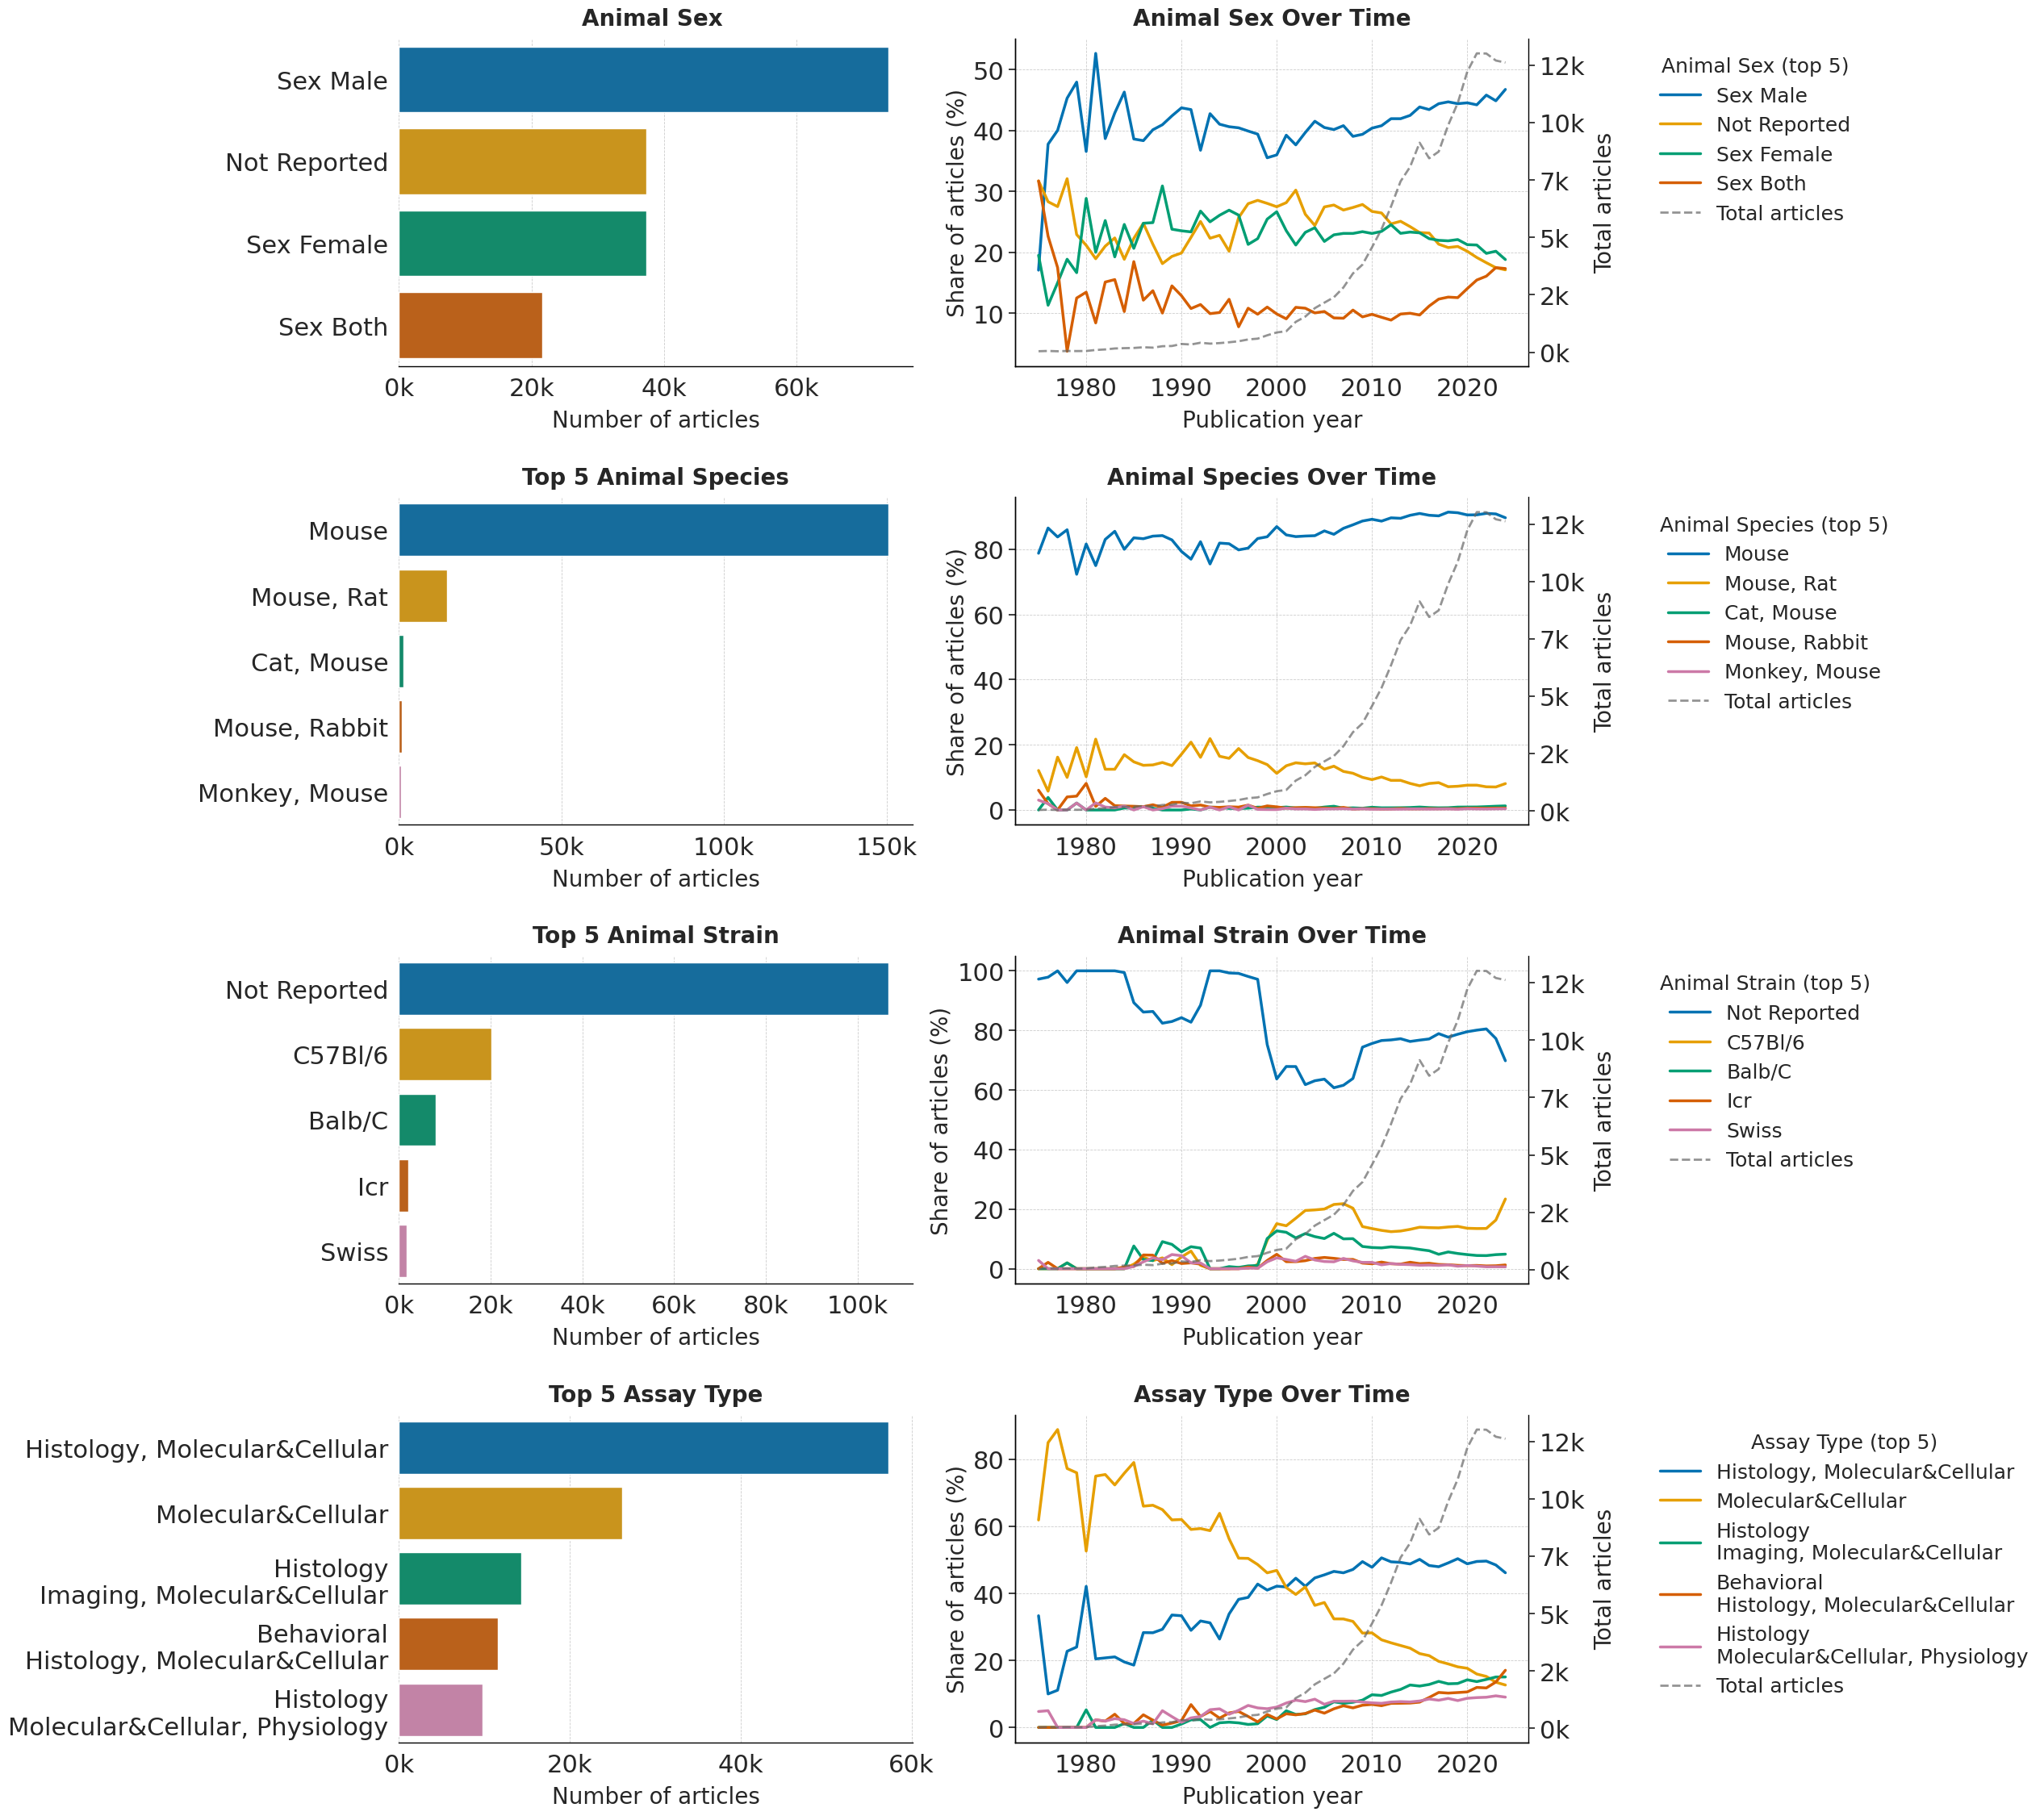

In [76]:
cols_to_plot = ['animal_sex', 'animal_species', 'animal_strain', 'assay_type']

visualize_columns_nature(
    dataset_fulltext,
    cols_to_plot,
    exclude_years=[2025],
    top_n=5,
    save_path = "viz/animal_studies_metadata.pdf"
)


## characteristics + rigor

In [51]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Your palette (black reserved)
colorblind10 = [
    "#000000",  # black (reserved)
    "#0072B2", # ✅ blue 
    "#E69F00", # ✅ orange 
    "#009E73", # ✅ bluish green 
    "#D55E00", # ✅ vermillion 
    "#CC79A7", # ✅ reddish purple 
    "#56B4E9", # ✅ sky/light blue 
    "#F0E442", # ✅ yellow
]


def _apply_nature_style():
    sns.set_theme(style="whitegrid", font_scale=1.4)
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Helvetica", "DejaVu Sans"],
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": "black",
        "axes.linewidth": 1.0,
        "axes.grid": True,
        "grid.linestyle": "--",
        "grid.linewidth": 0.6,
        "axes.labelsize": 20,
        "axes.titlesize": 20,
        "xtick.labelsize": 22,
        "ytick.labelsize": 22,
        "legend.fontsize": 18,
        "legend.title_fontsize": 18,
    })


def _wrap_label(val, max_items=2):
    val = str(val)
    if "," in val:
        parts = [p.strip() for p in val.split(",") if p.strip()]
        if len(parts) > max_items:
            mid = len(parts) // 2
            return ", ".join(parts[:mid]) + "\n" + ", ".join(parts[mid:])
    else:
        parts = [p.strip() for p in val.split(" ") if p.strip()]
        if len(parts) > 3:
            mid = len(parts) // 2
            return " ".join(parts[:mid]) + "\n" + " ".join(parts[mid:])
    return val

def display_label(val: str) -> str:
    # strip the "-present" suffix only for display
    return val.replace("-present", "").title()
    
def plot_selected_value_trends_row(
    df: pd.DataFrame,
    *,
    ax_bar,
    ax_trend,
    columns,
    values,
    year_col="year",
    min_year_count=25,
    exclude_years=None,
    title_left="Total frequency",
    title_right="Trends of selected categories over time",
    show_legend=False
):
    """
    Plot a single extra row:
      LEFT  – total counts for the selected (column,value) pairs
      RIGHT – % over time + total volume

    Does NOT create a new figure; draws into provided axes.
    """
    assert len(columns) == len(values), "`columns` and `values` must have the same length."

    df = df.copy()
    df[year_col] = pd.to_numeric(df[year_col], errors="coerce")
    if exclude_years is not None:
        df = df[~df[year_col].isin(exclude_years)]

    year_counts = df[year_col].value_counts()
    valid_years = year_counts[year_counts >= min_year_count].index
    df = df[df[year_col].isin(valid_years)].sort_values(by=year_col)

    total_per_year = df.groupby(year_col).size()

    # Compute totals for each selected (col,val)
    labels = []
    totals = []
    for col, val in zip(columns, values):
        labels.append(display_label(str(val)))
        totals.append(int((df[col].astype(str) == str(val)).sum()))

    totals_s = pd.Series(totals, index=labels)

    # Deterministic order: highest->lowest, tie-break by label
    totals_df = totals_s.reset_index()
    totals_df.columns = ["label", "count"]
    totals_df = totals_df.sort_values(["count", "label"], ascending=[False, True])

    ranked_labels = totals_df["label"].tolist()  # high->low
    totals_for_bar = totals_df.set_index("label")["count"].sort_values(ascending=True)

    # Rank palette excluding black (so black stays reserved)
    rank_palette = colorblind10[1:]

    if len(ranked_labels) > len(rank_palette):
        raise ValueError(
            f"Need more colors: {len(ranked_labels)} selected series but only {len(rank_palette)} colors."
        )

    color_map = {lab: rank_palette[i] for i, lab in enumerate(ranked_labels)}

    # LEFT: bar
    palette_dict = {lab: color_map[lab] for lab in totals_for_bar.index}
    sns.barplot(
        y=totals_for_bar.index,
        x=totals_for_bar.values,
        hue=totals_for_bar.index,
        palette=palette_dict,
        ax=ax_bar,
        dodge=False,
        legend=False,
    )
    ax_bar.invert_yaxis()
    ax_bar.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
    ax_bar.set_xlabel("Number of articles", labelpad=8)
    ax_bar.set_ylabel("")
    ax_bar.set_title(title_left, pad=12, weight="bold")
    ax_bar.tick_params(axis="both", labelsize=20)
    sns.despine(ax=ax_bar, left=True)

    # RIGHT: trends (%)
    for col, val in zip(columns, values):
        val = str(val)
        subset = df[df[col].astype(str) == val]
        yearly_counts = subset.groupby(year_col).size()
        share = (yearly_counts / total_per_year * 100).reindex(total_per_year.index).fillna(0)

        disp = display_label(val)
        ax_trend.plot(
            share.index,
            share.values,
            label=disp,
            color=color_map[disp],
            linewidth=2.5,
        )

    ax_twin = ax_trend.twinx()
    total_per_year.plot(
        ax=ax_twin,
        color="#666666",
        linestyle="--",
        linewidth=2,
        alpha=0.7,
        label="All articles",
    )

    ax_trend.set_xlabel("Publication year", labelpad=8)
    ax_trend.set_ylabel("Share of articles (%)")
    ax_twin.set_ylabel("All articles", labelpad=8)
    ax_twin.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
    ax_twin.grid(False)
    ax_trend.set_title(title_right, pad=12, weight="bold")
    sns.despine(ax=ax_trend, left=False, right=False)
    ax_trend.tick_params(axis="both", labelsize=20)
    if show_legend:
        h1, l1 = ax_trend.get_legend_handles_labels()
        h2, l2 = ax_twin.get_legend_handles_labels()
        ax_trend.legend(
            h1 + h2,
            l1 + l2,
            bbox_to_anchor=(1.22, 1),
            loc="upper left",
            frameon=False,
            title="Rigor Indicator",
            fontsize=22,          # ⬅ legend label size
            title_fontsize=24,    # ⬅ legend title size
        )
    else:
            ax_twin.legend(
                loc="upper left",
                frameon=True,
                fontsize=20,
            )


def visualize_columns_nature_composite(
    df,
    columns,
    *,
    year_col="year",
    top_n=10,
    min_year_count=25,
    exclude_years=None,
    save_path=None,
    # extra row
    extra_row_columns=None,
    extra_row_values=None,
    extra_row_title="Selected trends",
    show_legend=False
):
    """
    Multi-row composite:
      rows 0..len(columns)-1 : per-column (bar + trend)
      last row (optional)    : selected-trends (bar + trend)
    """
    _apply_nature_style()

    df = df.copy()
    df[year_col] = pd.to_numeric(df[year_col], errors="coerce")
    if exclude_years is not None:
        df = df[~df[year_col].isin(exclude_years)]

    year_counts = df[year_col].value_counts()
    valid_years = year_counts[year_counts >= min_year_count].index
    df = df[df[year_col].isin(valid_years)].sort_values(by=year_col)

    add_extra = extra_row_columns is not None and extra_row_values is not None
    n_rows = len(columns) + (1 if add_extra else 0)

    fig, axes = plt.subplots(
        n_rows, 2,
        figsize=(20, 6 * n_rows),
        gridspec_kw={"wspace": 0.2, "hspace": 0.4},
        squeeze=False,
    )

    # palette rules for the per-column plots
    BLACK = colorblind10[0]
    RESERVED_BLACK_LABELS = {"Not Reported", "Species Other"}
    rank_palette = colorblind10[1:]  # exclude black

    for i, col in enumerate(columns):
        ax_bar = axes[i, 0]
        ax_trend = axes[i, 1]

        # === Top-N deterministic ranking ===
        vc = df[col].dropna().astype(str).value_counts()
        top_df = vc.reset_index()
        top_df.columns = ["label", "count"]
        top_df = top_df.sort_values(["count", "label"], ascending=[False, True]).head(top_n)

        ranked_labels = top_df["label"].tolist()        # highest -> lowest
        top_values = top_df.set_index("label")["count"].sort_values(ascending=True)  # for bar display

        # build color_map:
        color_map = {}

        # reserved black labels
        for lab in ranked_labels:
            if lab in RESERVED_BLACK_LABELS:
                color_map[lab] = BLACK

        non_black_labels = [lab for lab in ranked_labels if lab not in RESERVED_BLACK_LABELS]
        if len(non_black_labels) > len(rank_palette):
            raise ValueError(
                f"Need more colors: {len(non_black_labels)} non-black categories but only {len(rank_palette)} colors."
            )
        for idx, lab in enumerate(non_black_labels):
            color_map[lab] = rank_palette[idx]

        # --- LEFT: barplot ---
        top_display = top_values.copy()
        top_display.index = [_wrap_label(v) for v in top_display.index]
        palette_dict = {_wrap_label(lab): color_map[lab] for lab in top_values.index}

        sns.barplot(
            y=top_display.index,
            x=top_display.values,
            hue=top_display.index,
            palette=palette_dict,
            ax=ax_bar,
            dodge=False,
            legend=False,
        )

        ax_bar.invert_yaxis()
        ax_bar.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
        ax_bar.set_xlabel("Number of articles", labelpad=8)
        ax_bar.set_ylabel("")
        display_col = col.replace("_"," ").title()
        if "sex" in col:
            ax_bar.set_title(f"{display_col} ", pad=12, weight="bold")
        else:
            ax_bar.set_title(f"Top {top_n} {display_col}", pad=12, weight="bold")
        sns.despine(ax=ax_bar, left=True)
        ax_bar.tick_params(axis="both", labelsize=20)
        
        # --- RIGHT: % over time ---
        subset = df[df[col].astype(str).isin(top_values.index)]
        trend_data = subset.groupby([year_col, col]).size().unstack(fill_value=0)

        ordered_cols = [lab for lab in ranked_labels if lab in trend_data.columns]  # highest->lowest
        trend_data = trend_data[ordered_cols]
        trend_pct = trend_data.div(trend_data.sum(axis=1), axis=0) * 100
        trend_pct = trend_pct.sort_index()
        total_per_year = df.groupby(year_col).size()

        for lab in ordered_cols:
            ax_trend.plot(
                trend_pct.index,
                trend_pct[lab],
                label=_wrap_label(lab),
                color=color_map[lab],
                linewidth=2.5,
            )

        ax_twin = ax_trend.twinx()
        total_per_year.plot(
            ax=ax_twin,
            color="#666666",
            linestyle="--",
            linewidth=2,
            alpha=0.7,
            label="All articles",
        )

        ax_trend.set_xlabel("Publication year", labelpad=8)
        ax_trend.set_ylabel("Share of articles (%)")
        ax_twin.set_ylabel("All articles", labelpad=8)
        ax_twin.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
        ax_twin.grid(False)
        ax_trend.set_title(f"{display_col} Over Time", pad=12, weight="bold")
        sns.despine(ax=ax_trend, left=False, right=False)
        ax_trend.set_ylim(0, 80)
        ax_trend.tick_params(axis="both", labelsize=20)
        if show_legend:
            h1, l1 = ax_trend.get_legend_handles_labels()
            h2, l2 = ax_twin.get_legend_handles_labels()
            ax_trend.legend(
                h1 + h2,
                l1 + l2,
                bbox_to_anchor=(1.22, 1),
                loc="upper left",
                frameon=False,
                title=f"{display_col}",
                fontsize=22,          # ⬅ legend label size
                title_fontsize=24,    # ⬅ legend title size
            )
        else:
            ax_twin.legend(
                loc="upper left",
                frameon=True,
                fontsize=20,
            )

    # ---- optional extra row at the bottom ----
    if add_extra:
        ax_bar = axes[-1, 0]
        ax_trend = axes[-1, 1]
        plot_selected_value_trends_row(
            df,
            ax_bar=ax_bar,
            ax_trend=ax_trend,
            columns=extra_row_columns,
            values=extra_row_values,
            year_col=year_col,
            min_year_count=min_year_count,
            exclude_years=exclude_years,
            title_left="Presence Of Rigor Indicators",
            title_right=extra_row_title,
        )

    plt.subplots_adjust(left=0.08, right=0.78, top=0.95, bottom=0.07)
    fig.patch.set_facecolor("white")


    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)

    plt.show()


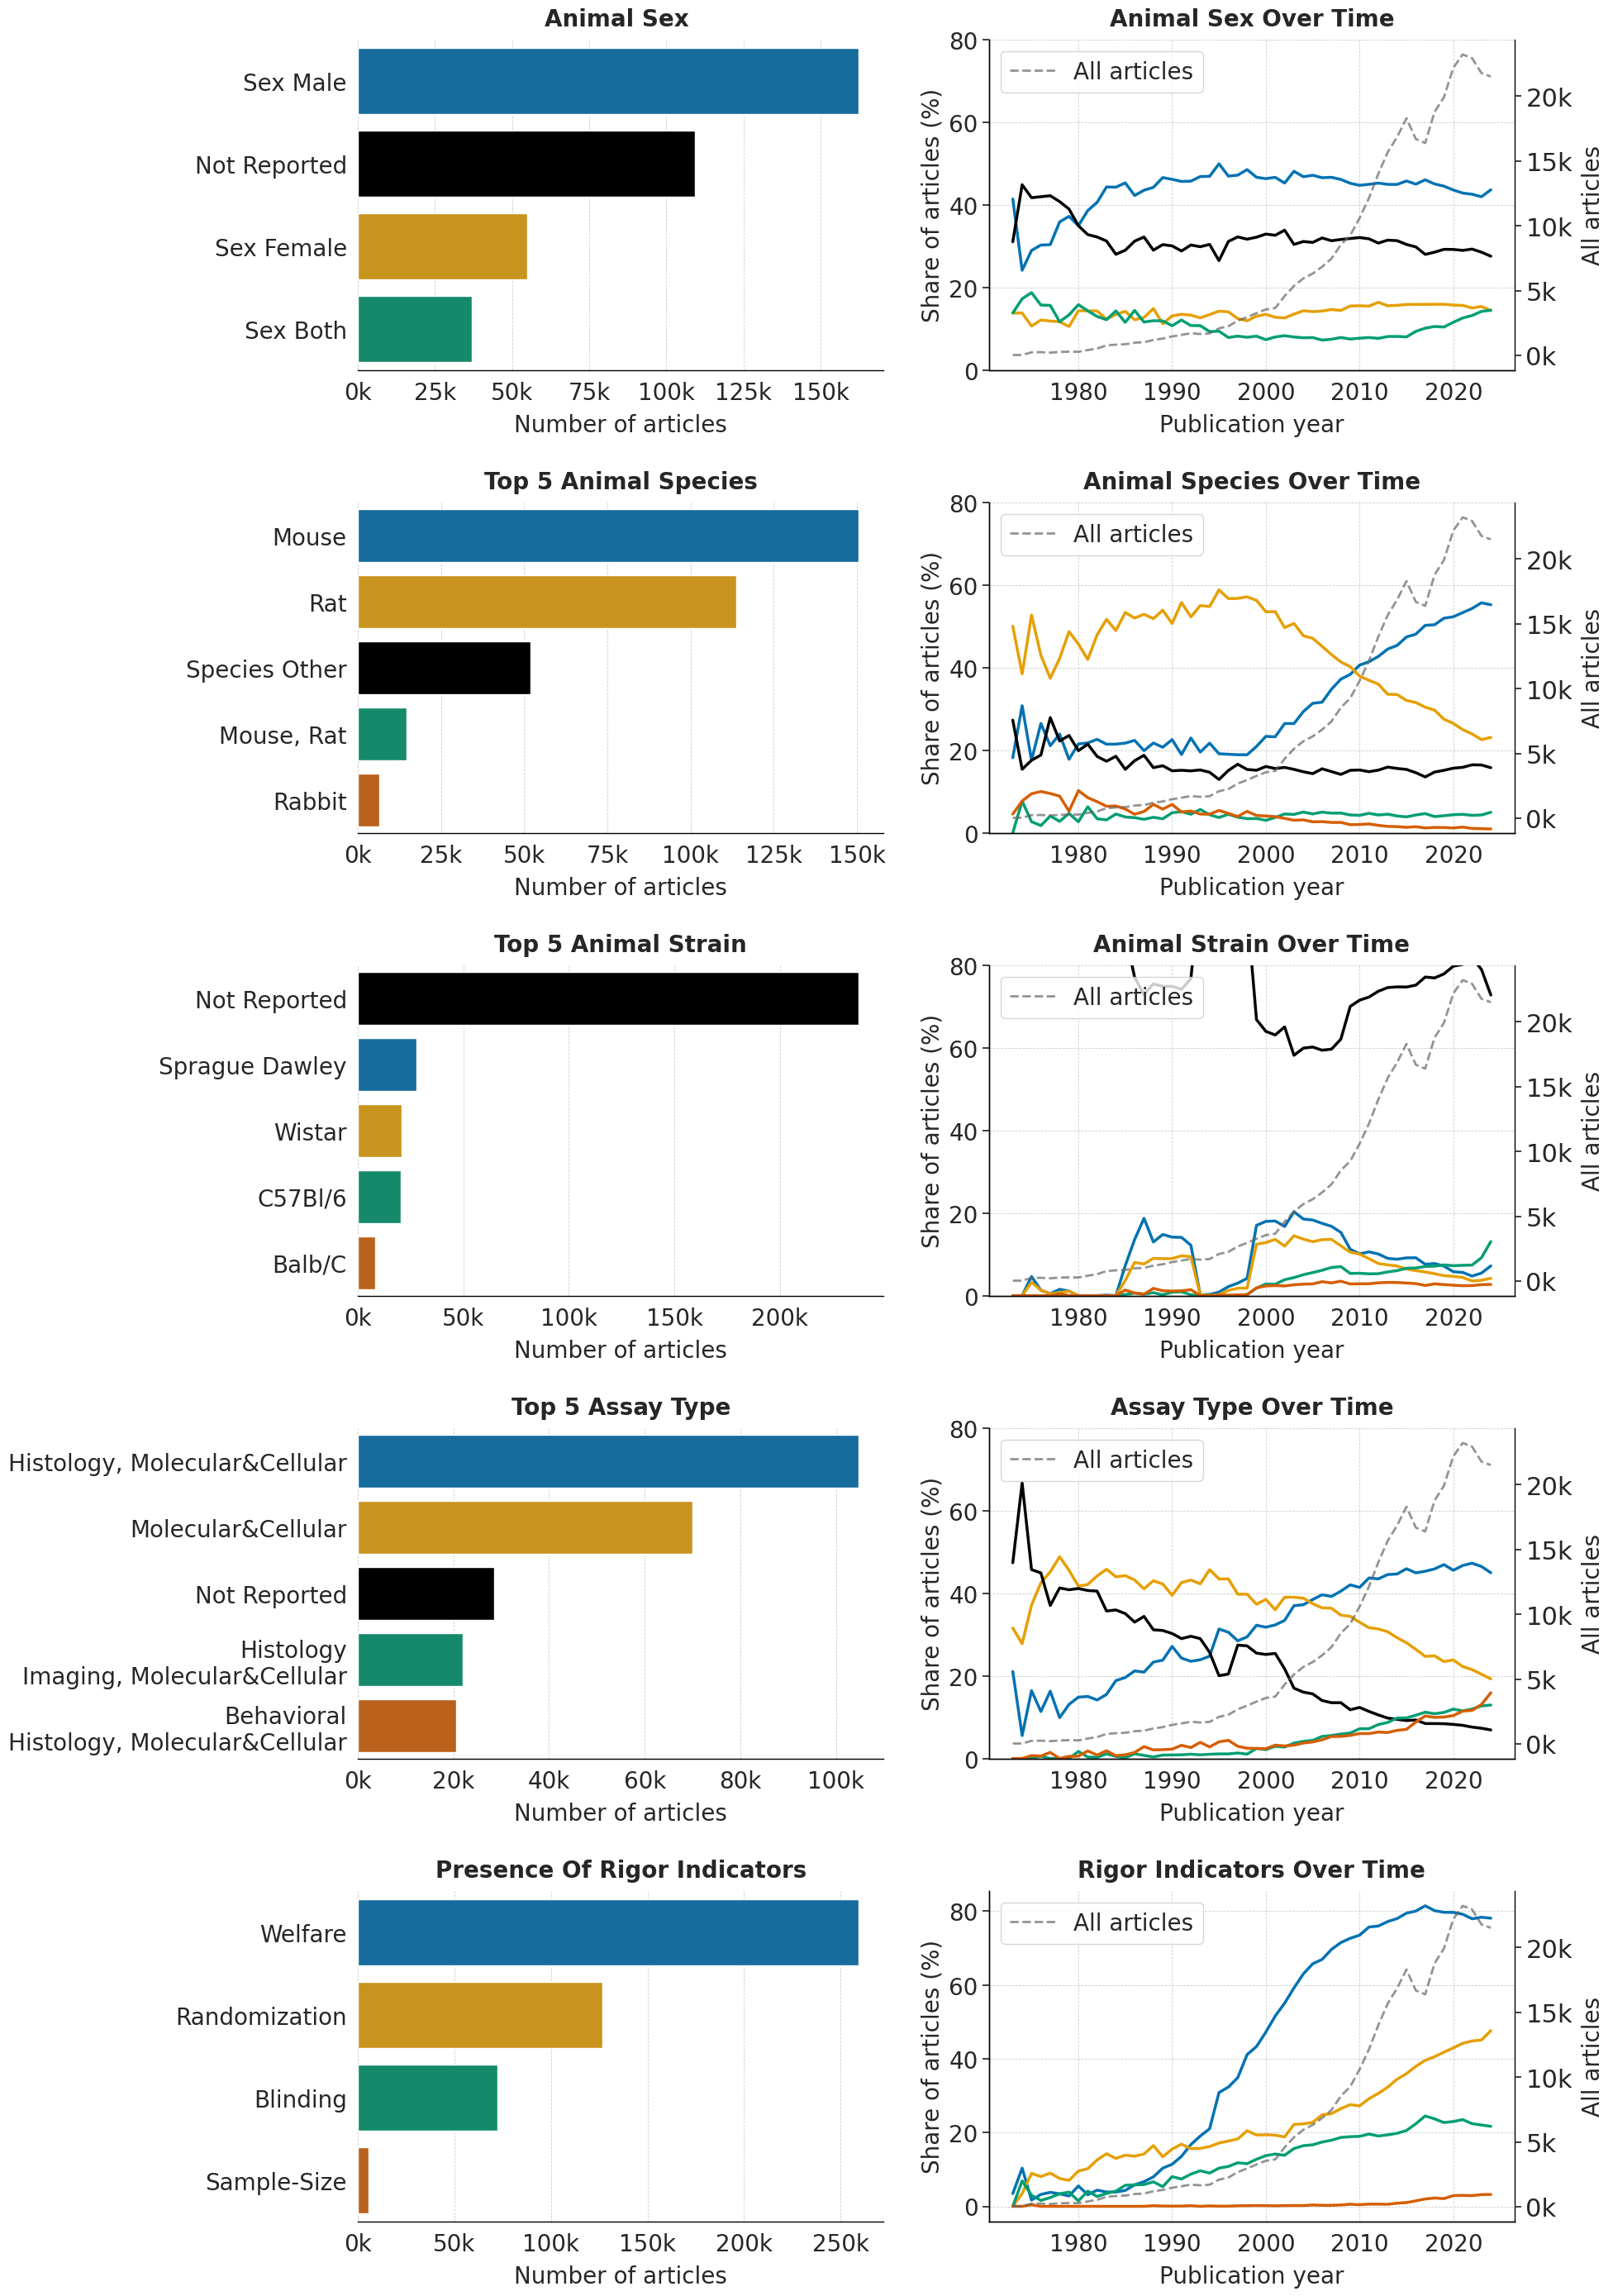

In [52]:
cols_to_plot = ["rigor_welfare", "rigor_randomization", "rigor_blinding", "sample_size"]

visualize_columns_nature_composite(
    dataset_fulltext,
    columns=['animal_sex', 'animal_species', 'animal_strain', 'assay_type'],
    top_n=5,
    exclude_years=[2025],
    min_year_count=25,
    save_path="viz/composite_with_rigor_row.pdf",
    extra_row_columns=cols_to_plot,
    extra_row_values=[
        "welfare-present",
        "randomization-present",
        "blinding-present",
        "sample-size-present",
    ],
    extra_row_title="Rigor Indicators Over Time",
)

In [15]:
def visualize_trends_nature_style(
    df,
    columns,
    year_col="year",
    top_n=10,
    min_year_count=25,
    exclude_years=None,
    max_cols=4,
    save_path=None
):
    """
    Nature-style visualization: trend-over-time plots for multiple categorical columns.

    Each column shows:
      - Top N categories by total frequency
      - % of articles over time (lines)
      - Total article volume (dashed grey line)
    Arranged in a grid (max 4 per row).

    Parameters
    ----------
    df : pd.DataFrame
        Dataframe with categorical columns and a year column.
    columns : list
        List of categorical columns to visualize.
    year_col : str
        Column name for publication year.
    top_n : int
        Number of top categories per variable to display.
    min_year_count : int
        Minimum number of papers required for a year to be included.
    exclude_years : list
        Optional list of years to exclude.
    max_cols : int
        Maximum number of subplots per row.
    save_path : str
        Optional path to save figure.
    """

    colorblind10 = [
        "#000000",  # black
        "#009E73",  # bluish green
        "#CC79A7",  # reddish purple
        "#8B4513",  # brown
        "#0072B2",  # blue
        "#E69F00",  # orange
        "#009E73",  # bluish green
        "#F0E442",  # yellow
        "#D55E00",  # vermillion red
        "#CC79A7",  # reddish purple
        "#56B4E9",  # light blue
        "#999999",  # grey
        
    ]


    # ---- Style setup ----
    sns.set_theme(style="whitegrid", font_scale=1.4)
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Helvetica", "DejaVu Sans"],
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": "black",
        "axes.linewidth": 1.0,
        "axes.grid": True,
        "grid.linestyle": "--",
        "grid.linewidth": 0.6,
        "axes.labelsize": 18,
        "axes.titlesize": 16,
        "xtick.labelsize": 17,
        "ytick.labelsize": 17,
        "legend.fontsize": 14,
        "legend.title_fontsize": 17,
    })

    # --- Filter valid years ---
    df[year_col] = pd.to_numeric(df[year_col], errors="coerce")
    if exclude_years is not None:
        df = df[~df[year_col].isin(exclude_years)]

    year_counts = df[year_col].value_counts()
    valid_years = year_counts[year_counts >= min_year_count].index
    df = df[df[year_col].isin(valid_years)].sort_values(by=year_col)

    total_per_year = df.groupby(year_col).size()

    # --- Determine grid ---
    n_cols = min(max_cols, len(columns))
    n_rows = math.ceil(len(columns) / n_cols)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(6 * n_cols, 5 * n_rows),
        sharex=True,
        gridspec_kw={"wspace": 0.25, "hspace": 0.4}
    )
    axes = axes.flatten() if len(columns) > 1 else [axes]

    for i, col in enumerate(columns):
        ax = axes[i]
    
        # Identify top N categories for this column
        top_values = df[col].value_counts().head(top_n).index
        subset = df[df[col].isin(top_values)]
    
        # Prepare trend data
        trend_data = subset.groupby([year_col, col]).size().unstack(fill_value=0)
        trend_pct = trend_data.div(trend_data.sum(axis=1), axis=0) * 100
    
        # Colors for top categories
        color_map = dict(zip(trend_pct.columns, colorblind10[:len(trend_pct.columns)]))
        line_colors = [color_map[v] for v in trend_pct.columns]
    
        # Plot % of articles
        trend_pct.plot(ax=ax, linewidth=2.2, color=line_colors)
        ax.set_ylim(0, 100)
        # Add total article volume (secondary axis)
        ax_twin = ax.twinx()
        total_per_year.plot(
            ax=ax_twin, color="#666666", linestyle="--", linewidth=2, alpha=0.7,
            label="Total articles"
        )
        ax_twin.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
        ax_twin.grid(False)
    
        # --- Axis label logic ---
        row_idx = i // n_cols
        col_idx = i % n_cols
    
        # Leftmost plots → left y-label
        if col_idx == 0:
            ax.set_ylabel("% of articles")
        else:
            ax.set_ylabel("")
            #ax.tick_params(labelleft=False)
    
        # Rightmost plots → right y-label
        if col_idx == n_cols - 1 or i == len(columns) - 1:
            ax_twin.set_ylabel("Total articles")
        else:
            ax_twin.set_ylabel("")
            #ax_twin.tick_params(labelright=False)
    
        # X-axis
        ax.set_xlabel("Year")
    
        # Title and styling
        ax.set_title(f"{col} – share over time", pad=10, weight="bold")
        sns.despine(ax=ax, left=False, right=False)
    
        # Legend
        handles, labels = ax.get_legend_handles_labels()
        handles2, labels2 = ax_twin.get_legend_handles_labels()
        ax.legend(
            handles + handles2,
            labels + labels2,
            loc="center left",
            frameon=False,
        )

    # Hide unused axes (if any)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.subplots_adjust(left=0.07, right=0.94, top=0.93, bottom=0.07)
    fig.patch.set_facecolor("white")

    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300, facecolor="white")

    plt.show()

In [233]:
dataset_fulltext["sample_size"].replace("sample-size-not-performed", "sample-size-not-reported", inplace=True)


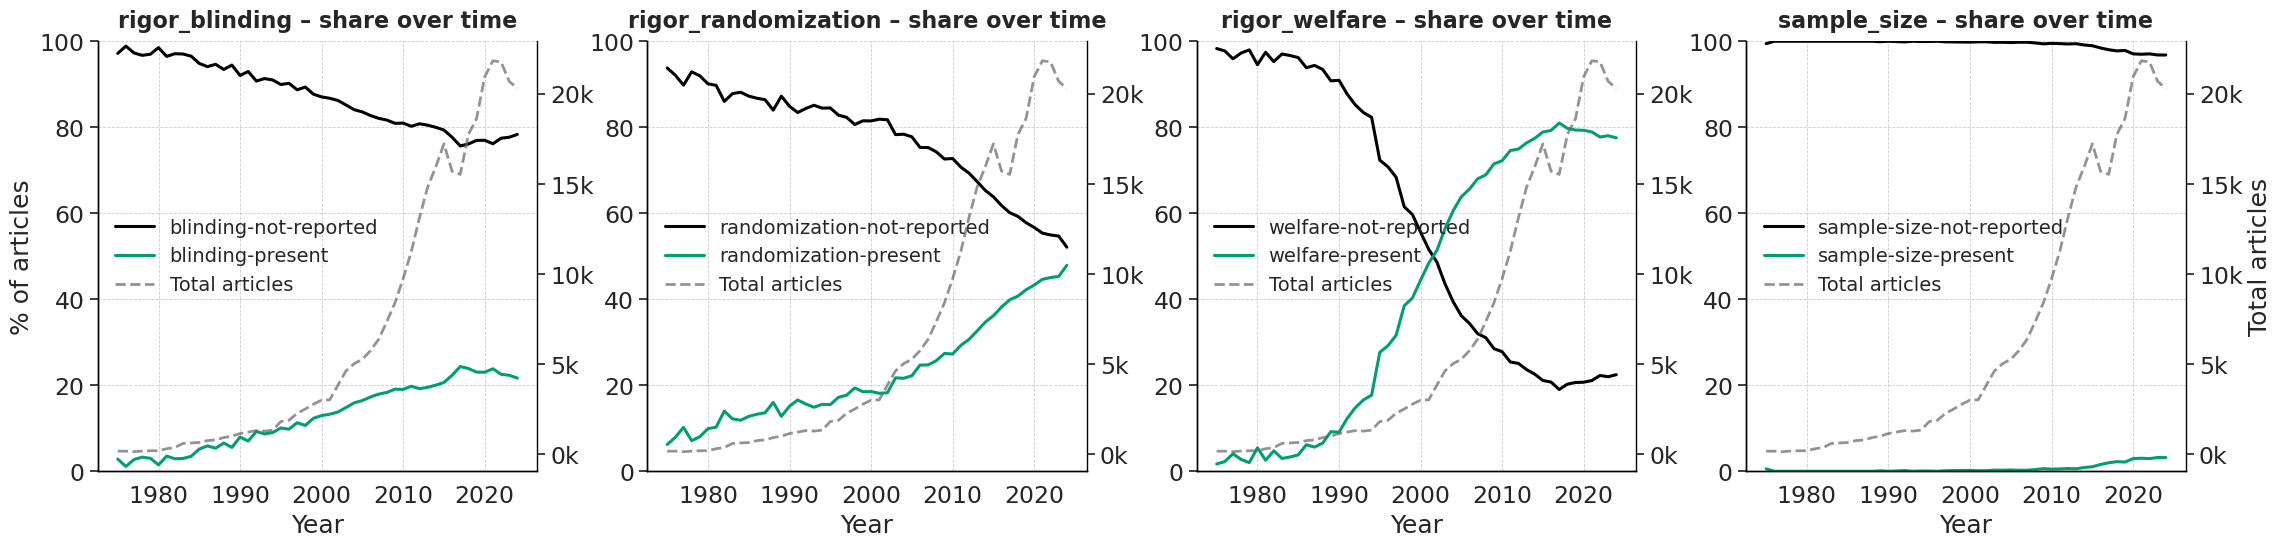

In [234]:
cols_to_plot = ['rigor_blinding', 'rigor_randomization', 'rigor_welfare', 'sample_size']
visualize_trends_nature_style(
    dataset_fulltext,
    cols_to_plot,
    exclude_years=[2025],
    save_path = "viz/animal_studies_rigor.pdf"
)


In [34]:
def visualize_selected_value_trends(
    df,
    columns,
    values,
    year_col="year",
    min_year_count=25,
    exclude_years=None,
    save_path=None
):
    """
    Nature-style visualization of trends for specific values from multiple columns.

    Each line represents the share of articles over time
    for one (column, value) pair, e.g. ('animal_species', 'mouse').

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    columns : list of str
        Categorical columns to visualize.
    values : list of str
        Specific values (one per column).
    year_col : str
        Column name for publication year.
    min_year_count : int
        Minimum number of papers required per year to be included.
    exclude_years : list
        Optional list of years to exclude.
    save_path : str
        Optional path to save the figure.
    """

    assert len(columns) == len(values), "`columns` and `values` must have the same length."

    colorblind10 = [
        "#000000", "#0072B2", "#E69F00", "#009E73",
        "#F0E442", "#D55E00", "#CC79A7", "#56B4E9",
        "#8B4513", "#999999"
    ]

    # --- Style ---
    sns.set_theme(style="whitegrid", font_scale=1.5)
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Helvetica", "DejaVu Sans"],
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": "black",
        "axes.linewidth": 1.0,
        "axes.grid": True,
        "grid.linestyle": "--",
        "grid.linewidth": 0.6,
        "axes.labelsize": 18,
        "axes.titlesize": 20,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 15,
        "legend.title_fontsize": 15,
    })

    # --- Prepare dataframe ---
    df[year_col] = pd.to_numeric(df[year_col], errors="coerce")
    if exclude_years is not None:
        df = df[~df[year_col].isin(exclude_years)]

    year_counts = df[year_col].value_counts()
    valid_years = year_counts[year_counts >= min_year_count].index
    df = df[df[year_col].isin(valid_years)].sort_values(by=year_col)

    total_per_year = df.groupby(year_col).size()

    # --- Plot setup ---
    fig, ax = plt.subplots(figsize=(10, 6))

    for i, (col, val) in enumerate(zip(columns, values)):
        subset = df[df[col] == val]
        yearly_counts = subset.groupby(year_col).size()
        share = (yearly_counts / total_per_year * 100).reindex(total_per_year.index).fillna(0)

        ax.plot(
            share.index,
            share.values,
            label=f"{val}",
            color=colorblind10[i % len(colorblind10)],
            linewidth=2.5
        )

    # --- Total papers (secondary y-axis) ---
    ax_twin = ax.twinx()
    total_per_year.plot(
        ax=ax_twin,
        color="#666666",
        linestyle="--",
        linewidth=2,
        alpha=0.7,
        label="Total articles"
    )

    # --- Styling ---
    ax.set_xlabel("Publication year", labelpad=8)
    ax.set_ylabel("Share of articles (%)")
    ax_twin.set_ylabel("Total articles", labelpad=8)
    ax_twin.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
    ax_twin.grid(False)

    ax.set_title("Trends of selected categories over time", pad=12, weight="bold")
    sns.despine(ax=ax, left=False, right=False)

    # --- Legend outside ---
    handles, labels = ax.get_legend_handles_labels()
    handles2, labels2 = ax_twin.get_legend_handles_labels()
    ax.legend(
        handles + handles2,
        labels + labels2,
        #bbox_to_anchor=(1.15, 1),
        loc="upper left",
        frameon=False,
        #itle="Selected trends"
    )

    plt.subplots_adjust(left=0.08, right=0.78, top=0.93, bottom=0.07)
    fig.patch.set_facecolor("white")

    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300, facecolor="white")

    plt.show()

In [36]:
def visualize_selected_value_trends_row(
    df,
    columns,
    values,
    year_col="year",
    min_year_count=25,
    exclude_years=None,
    save_path=None,
):
    """
    Nature-style 1-row visualization for selected (column, value) pairs.

    LEFT  – total counts (bar chart)
    RIGHT – % of articles over time + total volume (grey dashed line)
    """

    assert len(columns) == len(values), "`columns` and `values` must have the same length."

    # --- Palette (rank-consistent, no black duplication here) ---
    palette = [
        "#0072B2", "#E69F00", "#009E73",
        "#D55E00", "#CC79A7", "#56B4E9",
        "#F0E442", "#8B4513", "#999999",
    ]

    # --- Style ---
    sns.set_theme(style="whitegrid", font_scale=1.4)
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Helvetica", "DejaVu Sans"],
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": "black",
        "axes.linewidth": 1.0,
        "axes.grid": True,
        "grid.linestyle": "--",
        "grid.linewidth": 0.6,
        "axes.labelsize": 20,
        "axes.titlesize": 20,
        "xtick.labelsize": 22,
        "ytick.labelsize": 22,
        "legend.fontsize": 18,
        "legend.title_fontsize": 18,
    })

    # --- Prepare dataframe ---
    df = df.copy()
    df[year_col] = pd.to_numeric(df[year_col], errors="coerce")
    if exclude_years is not None:
        df = df[~df[year_col].isin(exclude_years)]

    year_counts = df[year_col].value_counts()
    valid_years = year_counts[year_counts >= min_year_count].index
    df = df[df[year_col].isin(valid_years)].sort_values(by=year_col)

    total_per_year = df.groupby(year_col).size()

    # --- Compute total counts per selected value ---
    labels = []
    counts = []
    for col, val in zip(columns, values):
        labels.append(val)
        counts.append((df[col] == val).sum())

    counts_series = (
        pd.Series(counts, index=labels)
        .sort_values(ascending=True)
    )

    color_map = {
        lab: palette[i]
        for i, lab in enumerate(counts_series.index[::-1])
    }

    # --- Figure layout (1 row, 2 columns) ---
    fig, (ax_bar, ax_trend) = plt.subplots(
        1, 2, figsize=(20, 6),
        gridspec_kw={"wspace": 0.25}
    )

    # =========================
    # LEFT: total counts
    # =========================
    sns.barplot(
        y=counts_series.index,
        x=counts_series.values,
        hue=counts_series.index,
        palette={lab: color_map[lab] for lab in counts_series.index},
        ax=ax_bar,
        dodge=False,
        legend=False,
    )

    ax_bar.invert_yaxis()
    ax_bar.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k")
    )
    ax_bar.set_xlabel("Number of articles")
    ax_bar.set_ylabel("")
    ax_bar.set_title("Total frequency", weight="bold")
    sns.despine(ax=ax_bar, left=True)

    # =========================
    # RIGHT: % over time
    # =========================
    for lab, col in zip(labels, columns):
        subset = df[df[col] == lab]
        yearly_counts = subset.groupby(year_col).size()
        share = (
            yearly_counts / total_per_year * 100
        ).reindex(total_per_year.index).fillna(0)

        ax_trend.plot(
            share.index,
            share.values,
            label=lab,
            color=color_map[lab],
            linewidth=2.5,
        )

    # --- total papers (twin axis) ---
    ax_twin = ax_trend.twinx()
    total_per_year.plot(
        ax=ax_twin,
        color="#666666",
        linestyle="--",
        linewidth=2,
        alpha=0.7,
        label="Total articles",
    )

    ax_trend.set_xlabel("Publication year")
    ax_trend.set_ylabel("Share of articles (%)")
    ax_twin.set_ylabel("Total articles")
    ax_twin.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k")
    )
    ax_twin.grid(False)

    ax_trend.set_title("Trends of selected categories over time", weight="bold")
    sns.despine(ax=ax_trend, left=False, right=False)

    # --- Legend ---
    h1, l1 = ax_trend.get_legend_handles_labels()
    h2, l2 = ax_twin.get_legend_handles_labels()
    ax_trend.legend(
        h1 + h2,
        l1 + l2,
        bbox_to_anchor=(1.22, 1),
        loc="upper left",
        frameon=False,
    )

    plt.subplots_adjust(left=0.08, right=0.78, top=0.95, bottom=0.1)
    fig.patch.set_facecolor("white")

    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)

    plt.show()


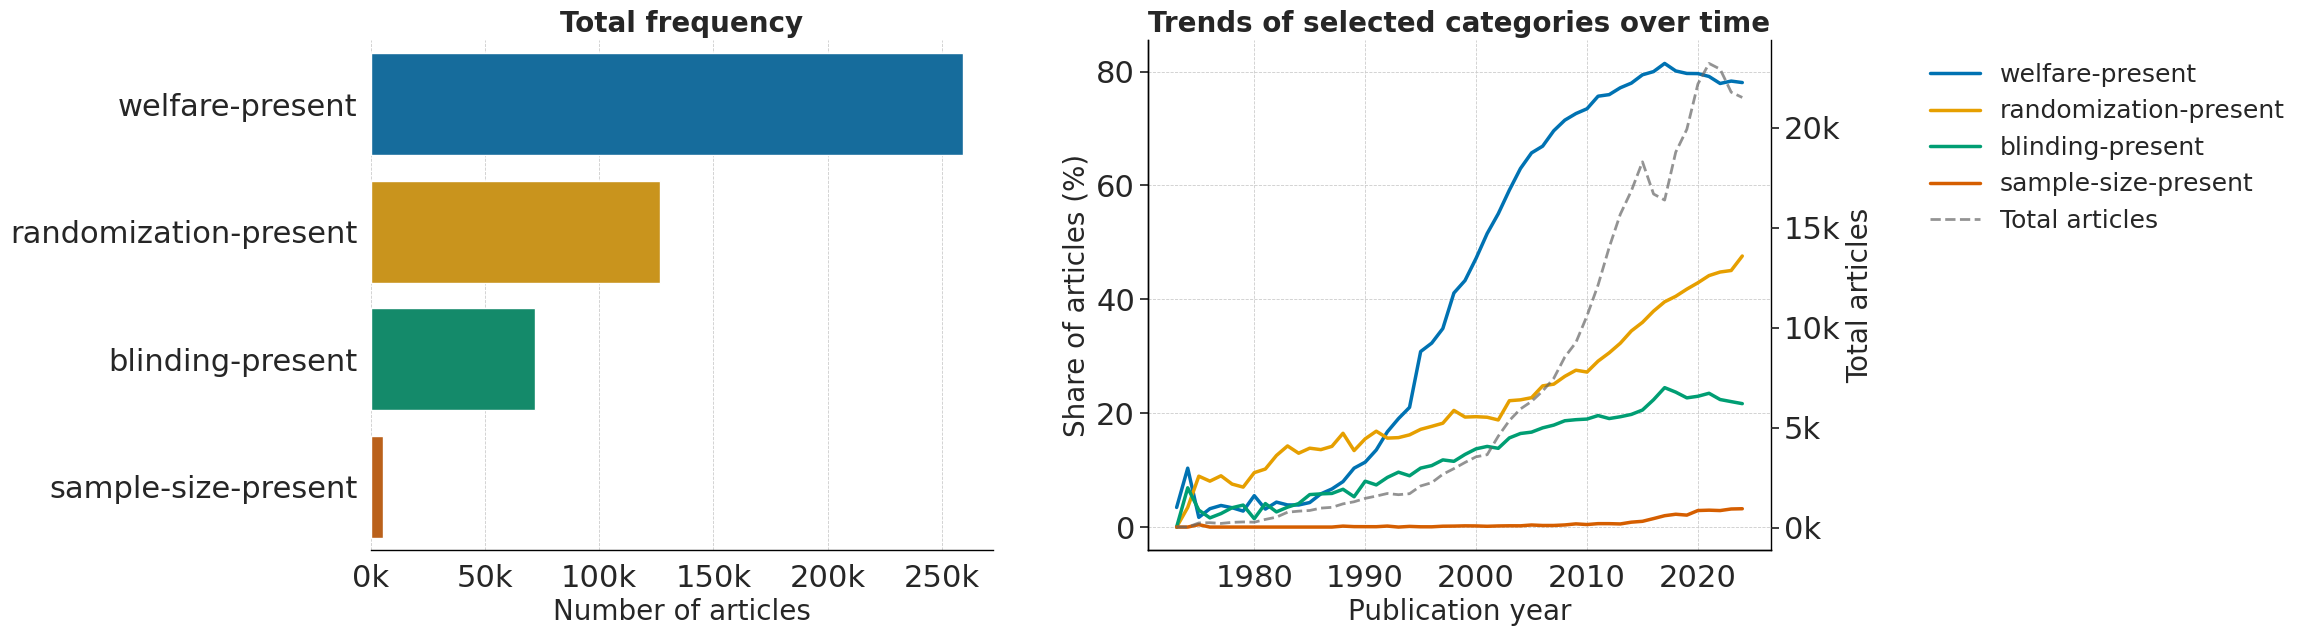

In [37]:
cols_to_plot = [
    "rigor_welfare",
    "rigor_randomization",
    "rigor_blinding",
    "sample_size",
]

visualize_selected_value_trends_row(
    dataset_fulltext,
    columns=cols_to_plot,
    values=[
        "welfare-present",
        "randomization-present",
        "blinding-present",
        "sample-size-present",
    ],
    exclude_years=[2025],
    min_year_count=25,
    save_path="viz/animal_studies_rigor_row.pdf",
)


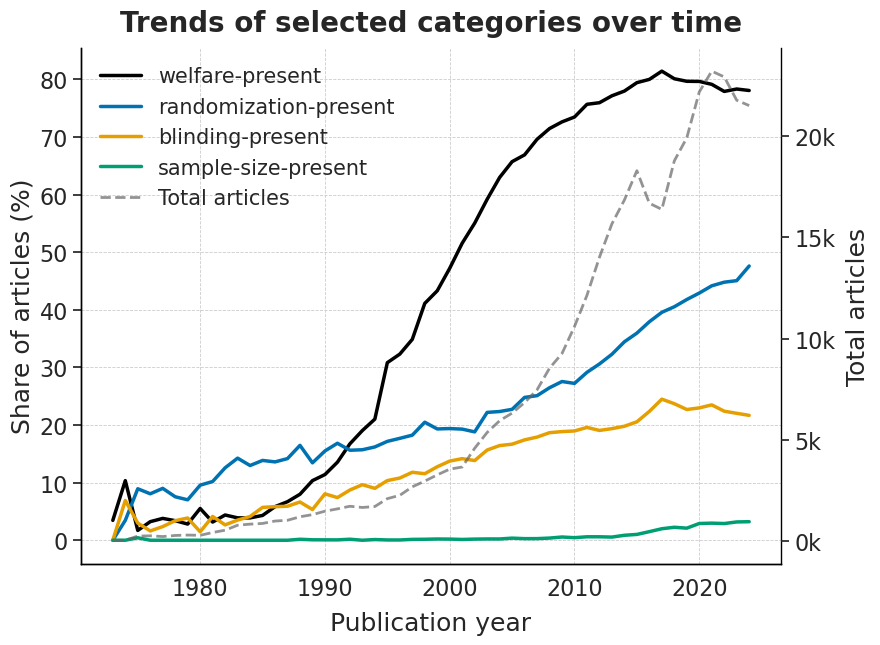

In [35]:
cols_to_plot = ['rigor_welfare',  'rigor_randomization', 'rigor_blinding', 'sample_size']

visualize_selected_value_trends(
    dataset_fulltext,
    columns=cols_to_plot,
    values=["welfare-present",  "randomization-present", "blinding-present",  "sample-size-present"],
    exclude_years=[2025],
    min_year_count=25,
    save_path = "viz/animal_studies_rigor_single.pdf"
)

# Metadata


In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

def visualize_bars_and_trend(
    df,
    columns,
    year_col="year",
    top_n=10,
    min_year_count=100,
    exclude_years=None,
    save_path=None,
    show_legend=False
):
    """
    Nature-style figure with two bar plots and one trend plot in a single row.

    - First column → independent bar chart.
    - Second column → bar chart (shares colors with trend plot).
    - Third column → trend line plot (% over time).
    - Long category labels automatically wrapped after the 5th word.
    """

    assert len(columns) == 3, "Please provide exactly 3 columns."

    colorblind10 = [
        "#000000", "#009E73", "#CC79A7", "#8B4513",
        "#0072B2", "#E69F00", "#F0E442", "#D55E00",
        "#56B4E9", "#999999"
    ]

    # ---- Style setup ----
    sns.set_theme(style="whitegrid", font_scale=1.4)
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Helvetica", "DejaVu Sans"],
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": "black",
        "axes.linewidth": 1.0,
        "axes.grid": True,
        "grid.linestyle": "--",
        "grid.linewidth": 0.6,
        "axes.labelsize": 22,
        "axes.titlesize": 20,
        "xtick.labelsize": 21,
        "ytick.labelsize": 21,
        "legend.fontsize": 18,
        "legend.title_fontsize": 21,
    })

    # --- Helper: wrap long labels after 5 words ---
    def wrap_label(label, max_words=3):
        if isinstance(label, str):
            words = label.split(" ")
            if len(words) > max_words:
                return " ".join(words[:max_words]) + "\n" + " ".join(words[max_words:])
        return label

    # --- Clean and filter ---
    df[year_col] = pd.to_numeric(df[year_col], errors="coerce")
    if exclude_years is not None:
        df = df[~df[year_col].isin(exclude_years)]

    year_counts = df[year_col].value_counts()
    valid_years = year_counts[year_counts >= min_year_count].index
    df = df[df[year_col].isin(valid_years)]

    total_per_year = df.groupby(year_col).size()

    # Consistent color map for 2nd & 3rd columns
    shared_col = columns[1]
    trend_col = columns[2]

    top_shared_values = df[shared_col].value_counts().head(top_n).index
    consistent_color_map = dict(zip(top_shared_values, colorblind10[:len(top_shared_values)]))

    # --- Setup figure ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), gridspec_kw={"wspace": 0.35})

    # === BAR 1 (independent colors) ===
    col = columns[0]
    ax = axes[0]
    top_values = df[col].value_counts().head(top_n).sort_values(ascending=False)
    sns.barplot(
        y=[wrap_label(v) for v in top_values.index],  # 🟢 wrapped labels
        x=top_values.values,
        ax=ax,
        palette=colorblind10[:len(top_values)]
    )
    display_col = col.replace("_"," ").title()
    ax.set_title(f"Top {top_n} {display_col}", pad=10, weight="bold")
    ax.set_xlabel("Number of articles")
    ax.set_ylabel("")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
    sns.despine(ax=ax, left=True)

    # === BAR 2 (shares colors with trend plot) ===
    col = shared_col
    ax = axes[1]
    top_values = df[col].value_counts().head(top_n).sort_values(ascending=False)
    bar_colors = [consistent_color_map.get(v, "#BBBBBB") for v in top_values.index]

    sns.barplot(
        y=[wrap_label(v) for v in top_values.index],  # 🟢 wrapped labels
        x=top_values.values,
        ax=ax,
        palette=bar_colors
    )
    display_col = col.replace("_"," ").title()
    ax.set_title(f"Top {top_n} {display_col}", pad=10, weight="bold")
    ax.set_xlabel("Number of articles")
    ax.set_ylabel("")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
    sns.despine(ax=ax, left=True)

    # === TREND (3rd col, shares colors with 2nd) ===
    ax = axes[2]
    
    # --- Filter to top categories only ---
    top_cats = top_shared_values
    subset = df[df[trend_col].isin(top_cats)]
    
    # --- Compute total papers per year *within the subset* ---
    year_totals = subset.groupby(year_col).size()
    
    # 🟢 Keep only years with enough papers (within subset)
    valid_years = year_totals[year_totals >= min_year_count].index
    subset = subset[subset[year_col].isin(valid_years)]
    year_totals = year_totals[year_totals.index.isin(valid_years)]
    
    # --- Compute trend data ---
    trend_data = subset.groupby([year_col, trend_col]).size().unstack(fill_value=0)
    trend_data = trend_data[[cat for cat in top_values.index if cat in trend_data.columns]]
    trend_pct = trend_data.div(trend_data.sum(axis=1), axis=0) * 100
    
    # 🟢 Ensure we only plot valid years, sorted chronologically
    trend_pct = trend_pct.loc[sorted(valid_years)]
    year_totals = year_totals.loc[sorted(valid_years)]
    
    # 🟢 Define colors here (AFTER we know trend_pct columns)
    line_colors = [consistent_color_map.get(v, "#BBBBBB") for v in trend_pct.columns]
    
    # --- Plot ---
    trend_pct.plot(ax=ax, linewidth=2.2, color=line_colors, legend=False)

    # Total articles (secondary axis)
    ax_twin = ax.twinx()
    year_totals.plot(   # 🟢 use the filtered subset, not total_per_year
        ax=ax_twin,
        color="#666666",
        linestyle="--",
        linewidth=2,
        alpha=0.7,
        label="Total articles"
    )

    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax_twin.grid(False)
    ax_twin.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))

    ax.set_xlabel("Year")
    ax.set_ylabel("% of articles")
    ax_twin.set_ylabel("Total articles")
    display_col = trend_col.replace("_"," ").title()
    ax.set_title(f"{display_col} Over Time", pad=10, weight="bold")

    sns.despine(ax=ax, left=False, right=False)

    # Legend
    if show_legend:
        handles, labels = ax.get_legend_handles_labels()
        handles2, labels2 = ax_twin.get_legend_handles_labels()
        ax.legend(
            handles + handles2,
            labels + labels2,
            bbox_to_anchor=(1.25, 1),  # 🟢 move outside to the right
            loc="upper left",
            frameon=False,
            #title=f"Top {top_n} {trend_col}",
        )

    # --- Final layout ---
    plt.subplots_adjust(left=0.07, right=0.95, top=0.90, bottom=0.10)
    fig.patch.set_facecolor("white")

    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300, facecolor="white")

    plt.show()


/tmp/ipykernel_2133017/4266134132.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_2133017/4266134132.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


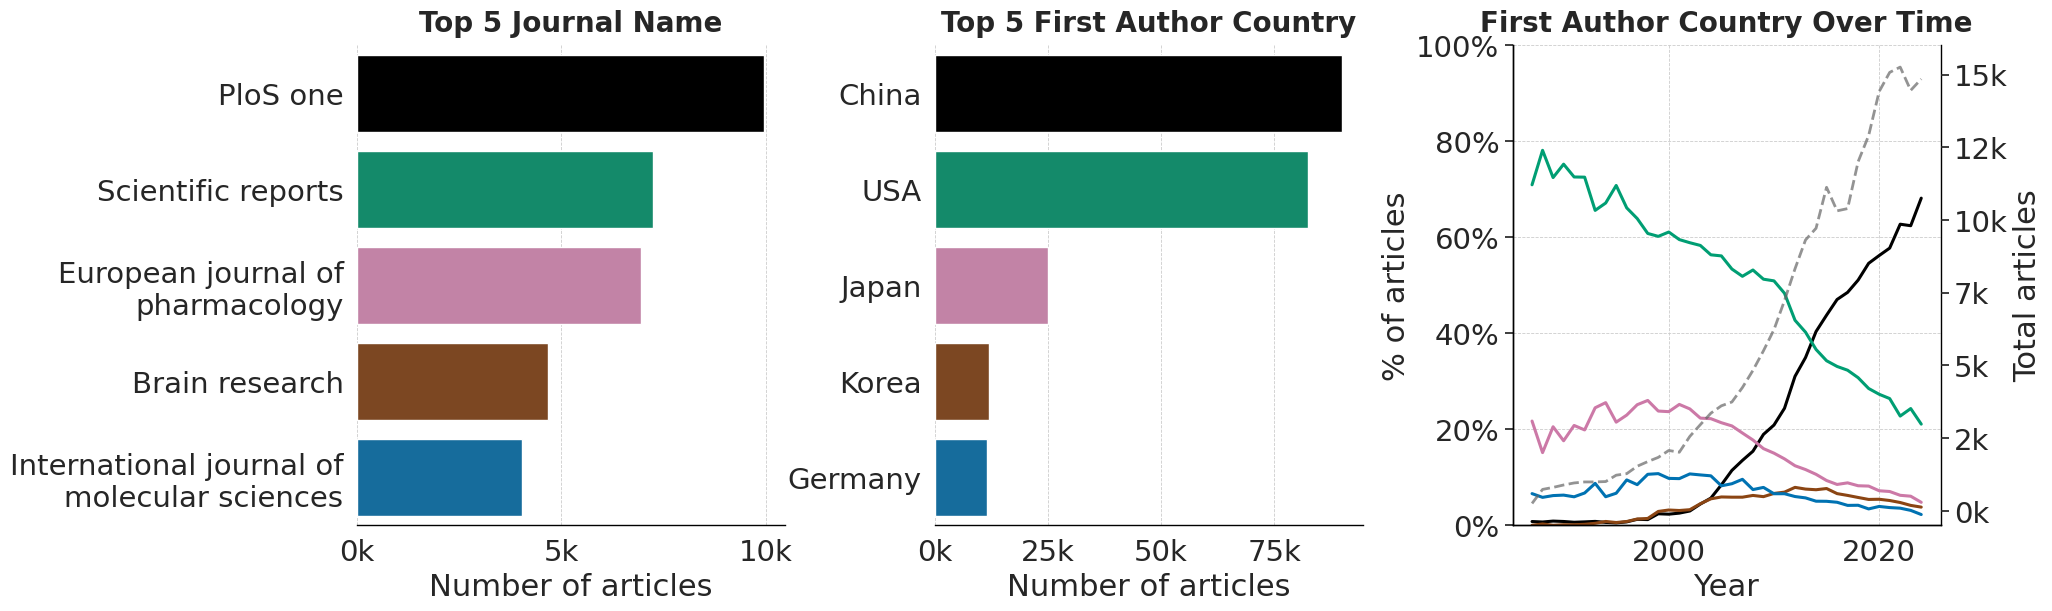

In [56]:
visualize_bars_and_trend(
    dataset_fulltext,
    columns=["journal_name", "first_author_country", "first_author_country"],
    year_col="year",
    exclude_years=[2025],
    top_n=5,
    save_path = "viz/animal_studies_journal_country.pdf"
)

In [171]:
df = dataset_fulltext.copy()
trend_col = "first_author_country"
year_col="year"
top_shared_values = df[trend_col].value_counts().head(10).index
min_year_count = 25

top_cats = top_shared_values
subset = df[df[trend_col].isin(top_cats)]

# --- Compute total papers per year ---
year_totals = subset.groupby(year_col).size()

# 🟢 Keep only years with enough papers
valid_years = year_totals[year_totals >= min_year_count].index
subset = subset[subset[year_col].isin(valid_years)]
year_totals = year_totals[year_totals.index.isin(valid_years)]

# --- Compute trend data ---
trend_data = subset.groupby([year_col, trend_col]).size().unstack(fill_value=0)
trend_pct = trend_data.div(trend_data.sum(axis=1), axis=0) * 100

In [187]:
test_df = dataset_fulltext[['PMID','year','first_author_country']]
test_df[test_df['year']==1980].first_author_country.unique()

array(['unlabeled'], dtype=object)